### Suggested Ensemble Method: Averaging Regressor

### Imports

In [1]:
# !pip install scikit-learn
# !pip install pycaret
# !pip install pyswarm

In [2]:
# Data handling & visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Preprocessing & transformations
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Ensemble models
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, VotingRegressor

# Gradient boosting libraries
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimization & utilities
from scipy.stats import randint, uniform
from tqdm.auto import tqdm
import joblib
import warnings
warnings.filterwarnings('ignore')

results_dir = "../results/"


### Load the dataset

### Cooling Optimization (Reduce Heat Gain)


- **Objective**: Minimize Cooling Load (Y2) to reduce overheating and energy consumption for cooling systems.

- **Problem Definition**: Determine the optimal combination of building features (X1–X8) that results in minimum cooling energy demand under given environmental conditions

In [3]:
data = pd.read_csv('../datasets/ENB2012_data.csv')
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2,Unnamed: 10,Unnamed: 11
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,15.55,21.33,NaN,NaN
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,15.55,21.33,NaN,NaN
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,15.55,21.33,NaN,NaN
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,15.55,21.33,NaN,NaN
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,20.84,28.28,NaN,NaN


In [4]:
data.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2',
       'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')

In [5]:
data = data.drop(["Unnamed: 10", "Unnamed: 11", "Y1"], axis=1)
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y2
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,28.28


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    float64
 6   X7      768 non-null    float64
 7   X8      768 non-null    float64
 8   Y2      768 non-null    float64
dtypes: float64(9)
memory usage: 91.3 KB


In [7]:
data.dropna(inplace=True)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    float64
 6   X7      768 non-null    float64
 7   X8      768 non-null    float64
 8   Y2      768 non-null    float64
dtypes: float64(9)
memory usage: 60.0 KB


In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
X1,768.0,0.764167,0.105777,0.62,0.6825,0.75,0.8300,0.98
X2,768.0,671.708333,88.086116,514.50,606.3750,673.75,741.1250,808.50
X3,768.0,318.500000,43.626481,245.00,294.0000,318.50,343.0000,416.50
X4,768.0,176.604167,45.165950,110.25,140.8750,183.75,220.5000,220.50
X5,768.0,5.250000,1.751140,3.50,3.5000,5.25,7.0000,7.00
X6,768.0,3.500000,1.118763,2.00,2.7500,3.50,4.2500,5.00
X7,768.0,0.234375,0.133221,0.00,0.1000,0.25,0.4000,0.40
X8,768.0,2.812500,1.550960,0.00,1.7500,3.00,4.0000,5.00
Y2,768.0,24.587760,9.513306,10.90,15.6200,22.08,33.1325,48.03


In [10]:
# Rename columns
data.columns = ["relative_compactness", "surface_area", "wall_area", "roof_area", "overall_height", "orientation", "glazing_area", "glazing_area_dist", "cooling_load"]

In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
relative_compactness,768.0,0.764167,0.105777,0.62,0.6825,0.75,0.8300,0.98
surface_area,768.0,671.708333,88.086116,514.50,606.3750,673.75,741.1250,808.50
wall_area,768.0,318.500000,43.626481,245.00,294.0000,318.50,343.0000,416.50
roof_area,768.0,176.604167,45.165950,110.25,140.8750,183.75,220.5000,220.50
overall_height,768.0,5.250000,1.751140,3.50,3.5000,5.25,7.0000,7.00
orientation,768.0,3.500000,1.118763,2.00,2.7500,3.50,4.2500,5.00
glazing_area,768.0,0.234375,0.133221,0.00,0.1000,0.25,0.4000,0.40
glazing_area_dist,768.0,2.812500,1.550960,0.00,1.7500,3.00,4.0000,5.00
cooling_load,768.0,24.587760,9.513306,10.90,15.6200,22.08,33.1325,48.03


In [12]:
data.relative_compactness.value_counts()

relative_compactness
0.98    64
0.90    64
0.86    64
0.82    64
0.79    64
0.76    64
0.74    64
0.71    64
0.69    64
0.66    64
0.64    64
0.62    64
Name: count, dtype: int64

In [13]:
data.overall_height.value_counts()

overall_height
7.0    384
3.5    384
Name: count, dtype: int64

In [14]:
data.orientation.value_counts()

orientation
2.0    192
3.0    192
4.0    192
5.0    192
Name: count, dtype: int64

In [15]:
data.glazing_area.value_counts()

glazing_area
0.10    240
0.25    240
0.40    240
0.00     48
Name: count, dtype: int64

In [16]:
data.glazing_area_dist.value_counts()

glazing_area_dist
1.0    144
2.0    144
3.0    144
4.0    144
5.0    144
0.0     48
Name: count, dtype: int64

### Exploratory Data Analysis

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   relative_compactness  768 non-null    float64
 1   surface_area          768 non-null    float64
 2   wall_area             768 non-null    float64
 3   roof_area             768 non-null    float64
 4   overall_height        768 non-null    float64
 5   orientation           768 non-null    float64
 6   glazing_area          768 non-null    float64
 7   glazing_area_dist     768 non-null    float64
 8   cooling_load          768 non-null    float64
dtypes: float64(9)
memory usage: 60.0 KB


In [18]:
data.head()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_dist,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,28.28


In [19]:
# data = data.sample(50, random_state=100)

In [20]:
# Group by number of cylinders and compute average mpg
avg_cooling_load = data.groupby("overall_height")["cooling_load"].mean().sort_values(ascending=False)

print("Buildings sorted by Overall Height:")
print(avg_cooling_load)

Buildings sorted by Overall Height:
overall_height
7.0    33.104089
3.5    16.071432
Name: cooling_load, dtype: float64


In [21]:
# Group by number of cylinders and compute average displacement
avg_displacement = data.groupby("orientation")["cooling_load"].mean().sort_values(ascending=False)

print("Buildings sorted by Orientation:")
print(avg_displacement)

Buildings sorted by Orientation:
orientation
5.0    24.953646
2.0    24.604531
4.0    24.480313
3.0    24.312552
Name: cooling_load, dtype: float64


In [22]:
# Group by number of cylinders and compute average horsepower
avg_horsepower = data.groupby("glazing_area")["cooling_load"].mean().sort_values(ascending=False)

print("Buildings sorted by Glazing Area:")
print(avg_horsepower)

Buildings sorted by Glazing Area:
glazing_area
0.40    26.911417
0.25    24.892625
0.10    22.935542
0.00    19.706250
Name: cooling_load, dtype: float64


In [23]:
# Group by number of cylinders and compute average weight
avg_cooling_load = data.groupby("glazing_area_dist")["cooling_load"].mean().sort_values(ascending=False)

print("Buidlings sorted by Glazing Area Distribution:")
print(avg_cooling_load)

Buidlings sorted by Glazing Area Distribution:
glazing_area_dist
1.0    25.179514
4.0    25.015139
2.0    24.996875
5.0    24.715000
3.0    24.659444
0.0    19.706250
Name: cooling_load, dtype: float64


In [24]:
data.columns

Index(['relative_compactness', 'surface_area', 'wall_area', 'roof_area',
       'overall_height', 'orientation', 'glazing_area', 'glazing_area_dist',
       'cooling_load'],
      dtype='object')

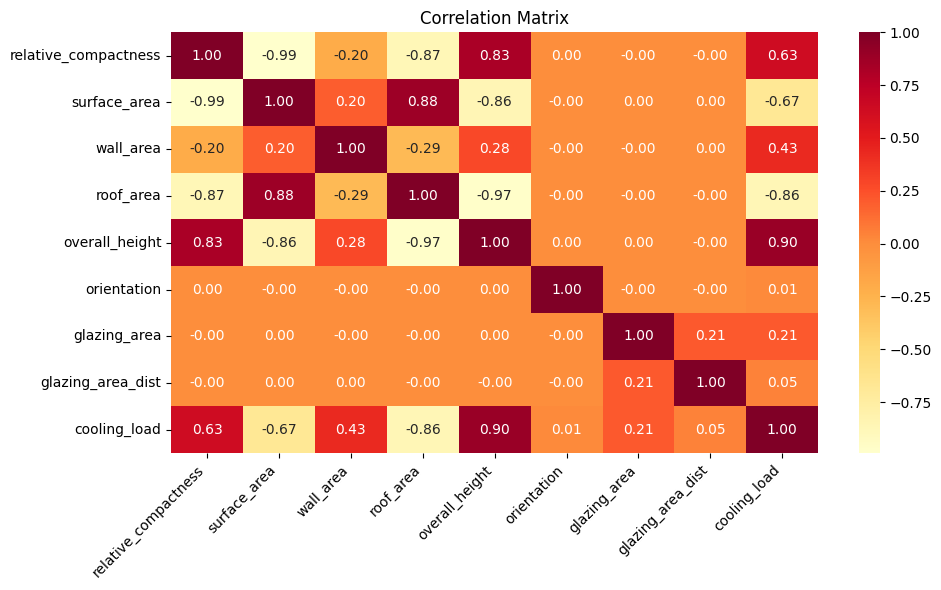

In [25]:
# Correlation Analysis
correlation_matrix = data.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="YlOrRd", fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(results_dir + "correlation_analysis.png", dpi=400)
plt.show()

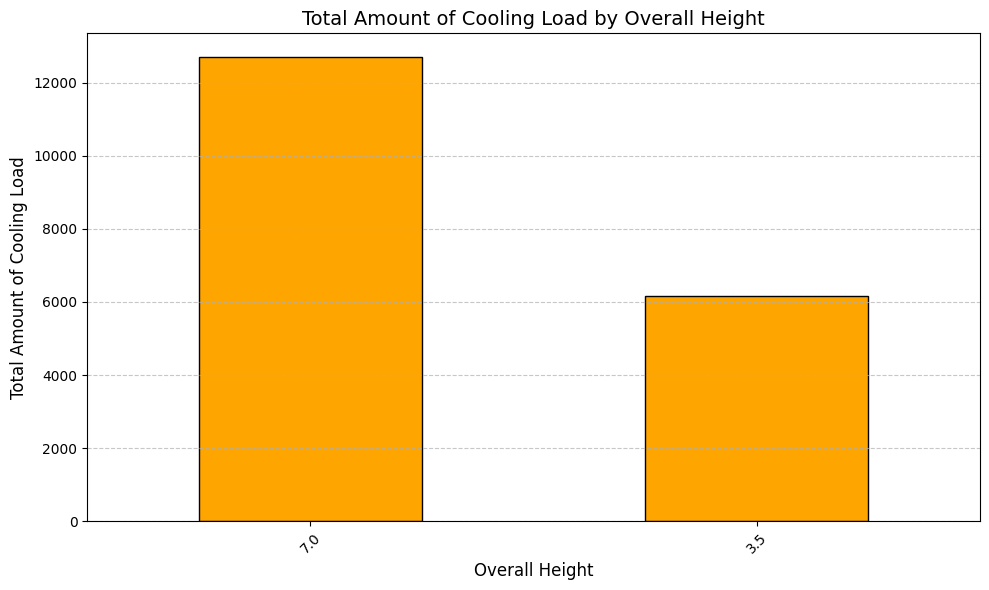

In [26]:
# Total MPG by Cylinders
total_mpg = data.groupby("overall_height")["cooling_load"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
total_mpg.plot(kind='bar', color='Orange', edgecolor='black')
plt.title("Total Amount of Cooling Load by Overall Height", fontsize=14)
plt.xlabel("Overall Height", fontsize=12)
plt.ylabel("Total Amount of Cooling Load", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "01_total_overall_height.png", dpi=400)
plt.show()

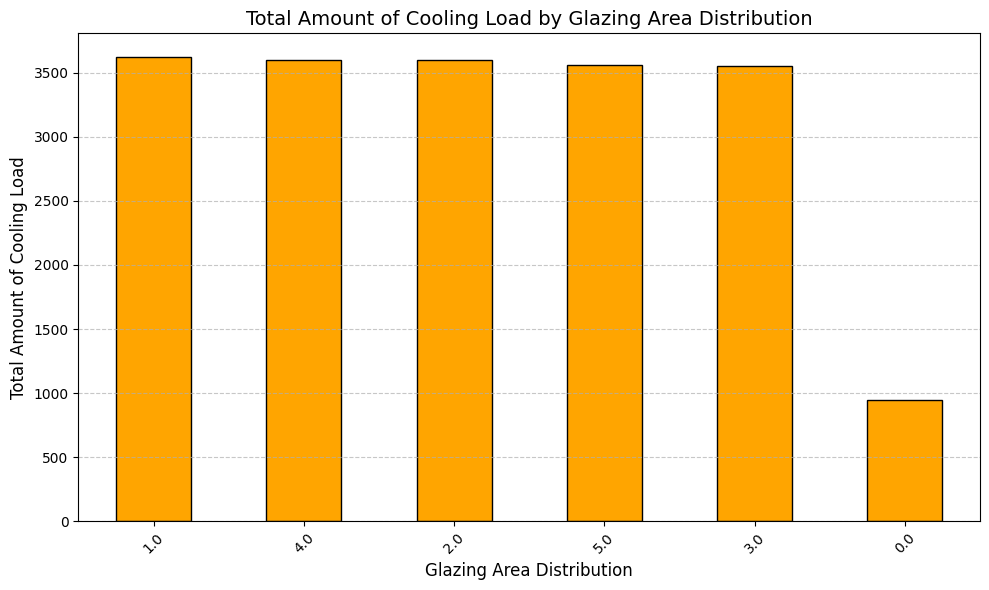

In [27]:
# Total MPG by Cylinders
total_mpg = data.groupby("glazing_area_dist")["cooling_load"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
total_mpg.plot(kind='bar', color='Orange', edgecolor='black')
plt.title("Total Amount of Cooling Load by Glazing Area Distribution", fontsize=14)
plt.xlabel("Glazing Area Distribution", fontsize=12)
plt.ylabel("Total Amount of Cooling Load", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "01_total_glazing_area_distribution.png", dpi=400)
plt.show()

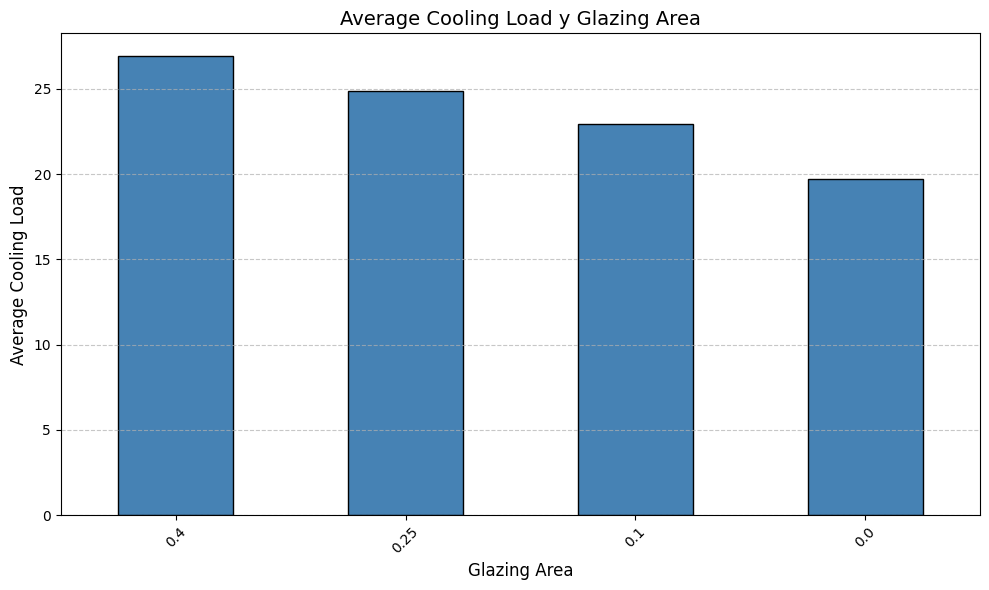

In [28]:
# Average MPG by Cylinders
avg_mpg = data.groupby("glazing_area")["cooling_load"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
avg_mpg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Average Cooling Load y Glazing Area", fontsize=14)
plt.xlabel("Glazing Area", fontsize=12)
plt.ylabel("Average Cooling Load", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "02_avg_cooling_load_by_grazing_area.png", dpi=400)
plt.show()

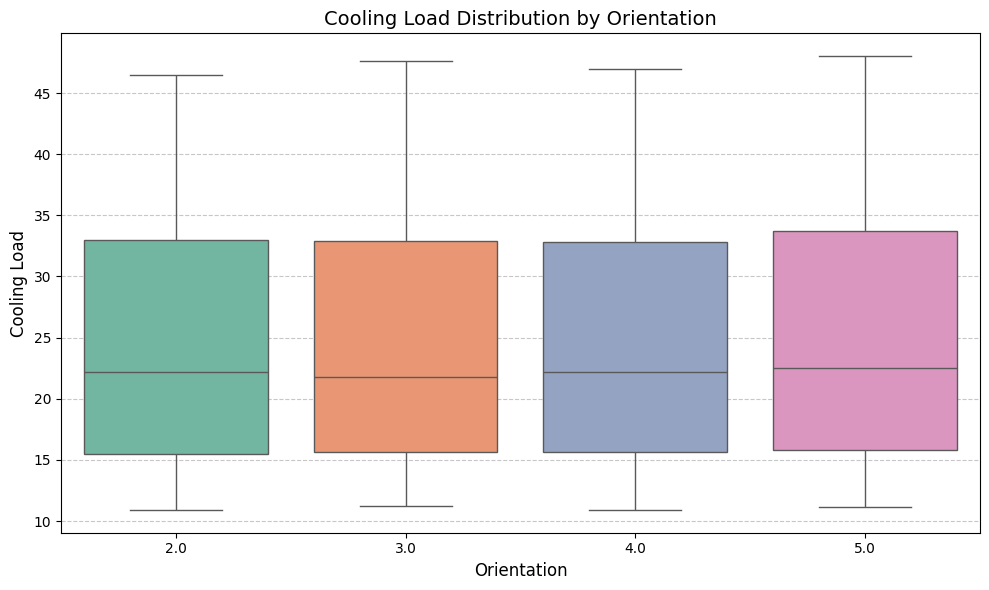

In [29]:
# Box Plot – MPG by Cylinders
plt.figure(figsize=(10, 6))
sns.boxplot(x="orientation", y="cooling_load", data=data, palette="Set2")
plt.title("Cooling Load Distribution by Orientation", fontsize=14)
plt.xlabel("Orientation", fontsize=12)
plt.ylabel("Cooling Load", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "03_boxplot_ooling_load_orientation.png", dpi=400)
plt.show()

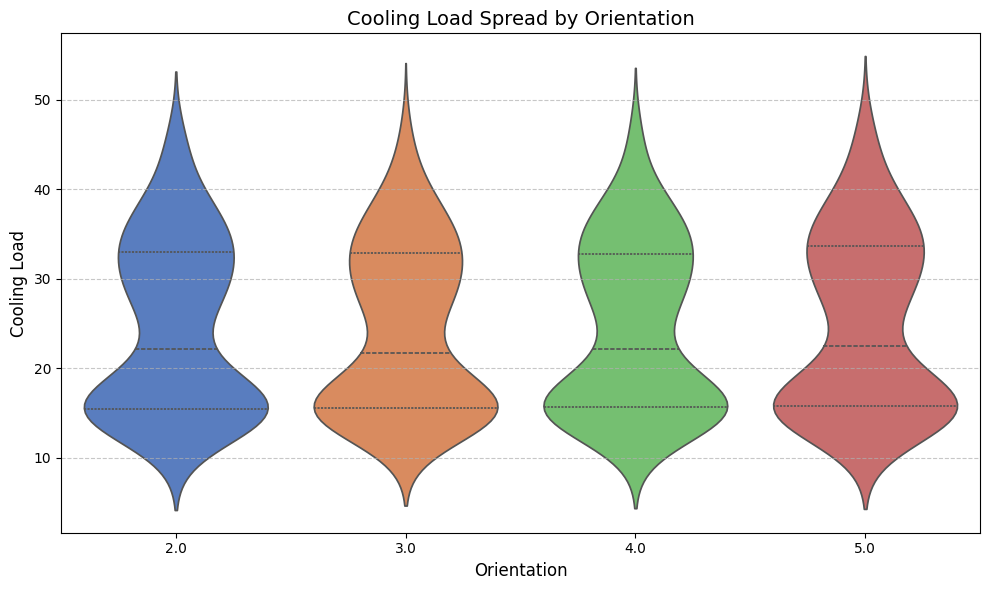

In [30]:
# Violin Plot – MPG by Cylinders
plt.figure(figsize=(10, 6))
sns.violinplot(x="orientation", y="cooling_load", data=data, palette="muted", inner="quartile")
plt.title("Cooling Load Spread by Orientation", fontsize=14)
plt.xlabel("Orientation", fontsize=12)
plt.ylabel("Cooling Load", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "04_violin_cooling_load_by_orientation.png", dpi=400)
plt.show()

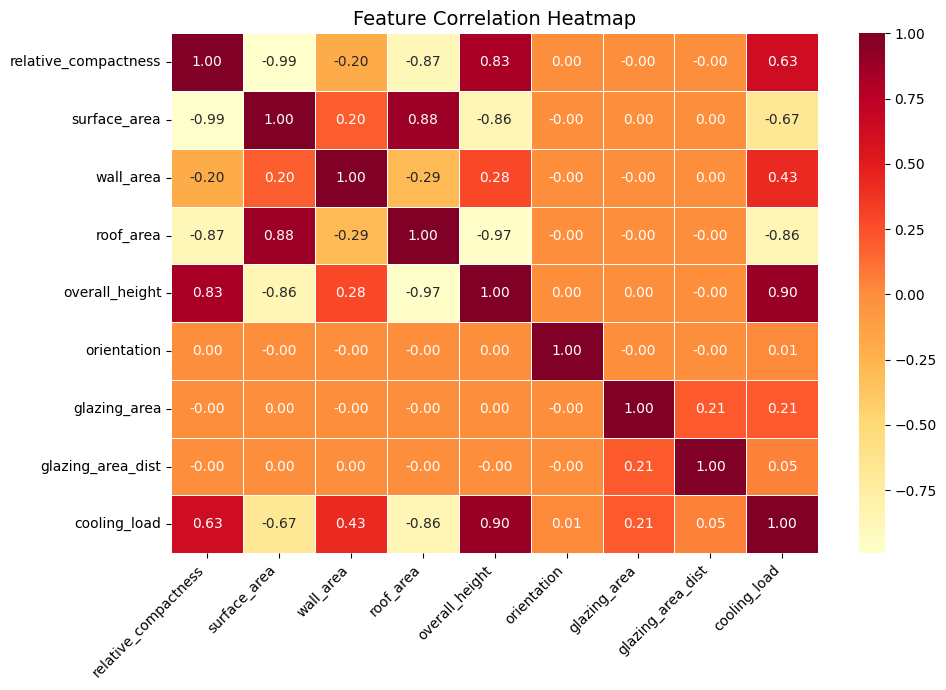

In [31]:
# Heatmap – Correlation Matrix
plt.figure(figsize=(10, 7))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(results_dir + "07_correlation_heatmap.png", dpi=400)
plt.show()

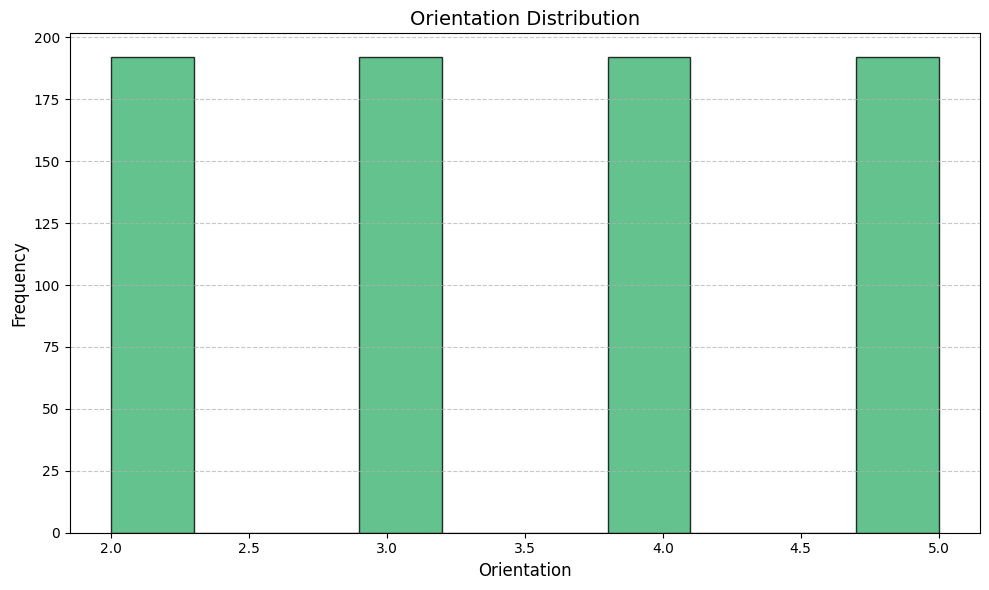

In [32]:
# Histogram – MPG Distribution
plt.figure(figsize=(10, 6))
plt.hist(data["orientation"], bins=10, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title("Orientation Distribution", fontsize=14)
plt.xlabel("Orientation", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "08_cooling_load_histogram.png", dpi=400)
plt.show()

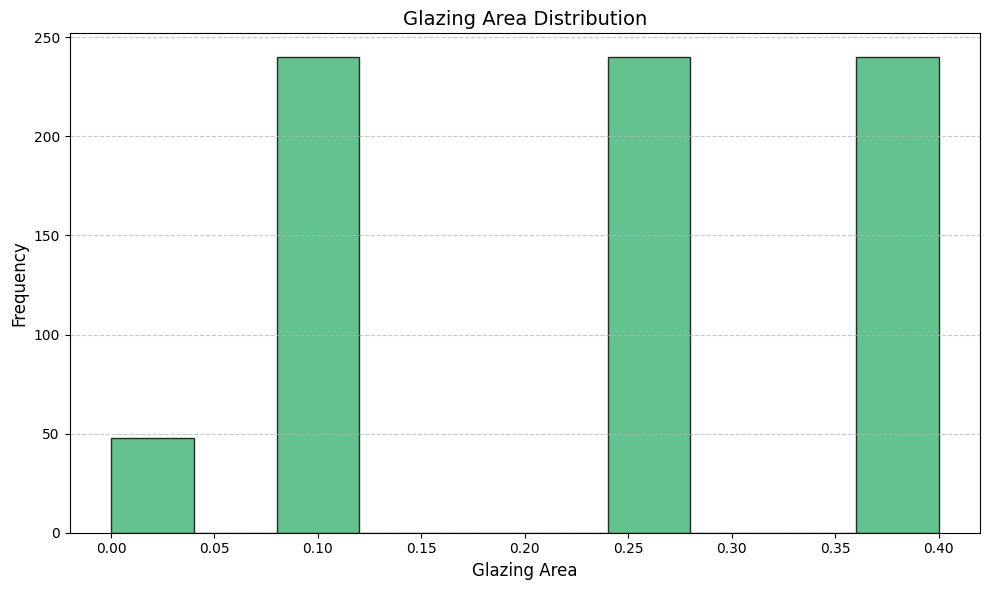

In [33]:
# Histogram – MPG Distribution
plt.figure(figsize=(10, 6))
plt.hist(data["glazing_area"], bins=10, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title("Glazing Area Distribution", fontsize=14)
plt.xlabel("Glazing Area", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "08_histogram_glazing_area.png", dpi=400)
plt.show()

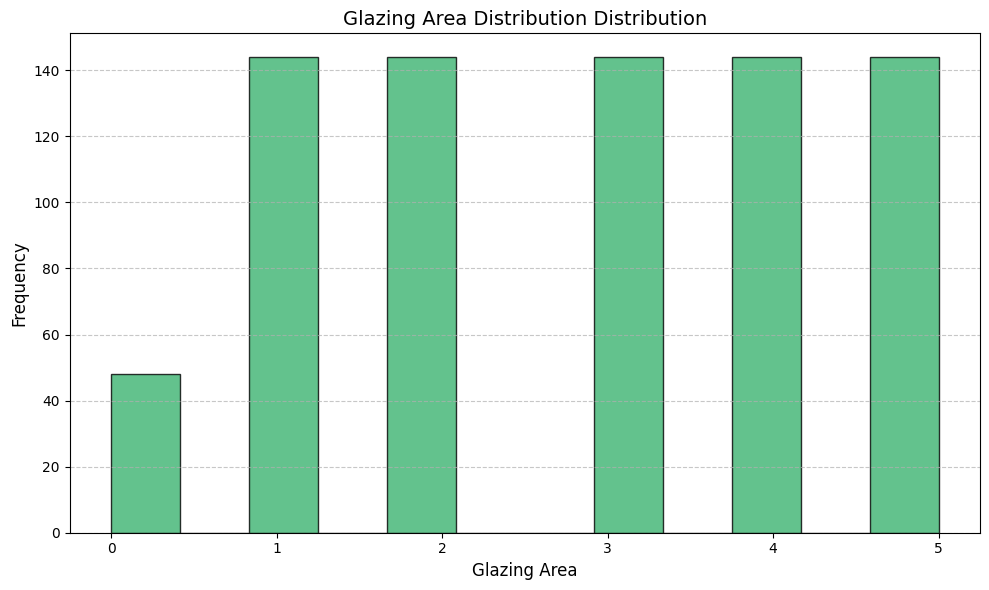

In [34]:
# Histogram – MPG Distribution
plt.figure(figsize=(10, 6))
plt.hist(data["glazing_area_dist"], bins=12, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title("Glazing Area Distribution Distribution", fontsize=14)
plt.xlabel("Glazing Area", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "08_histogram_glazing_area_distribution.png", dpi=400)
plt.show()

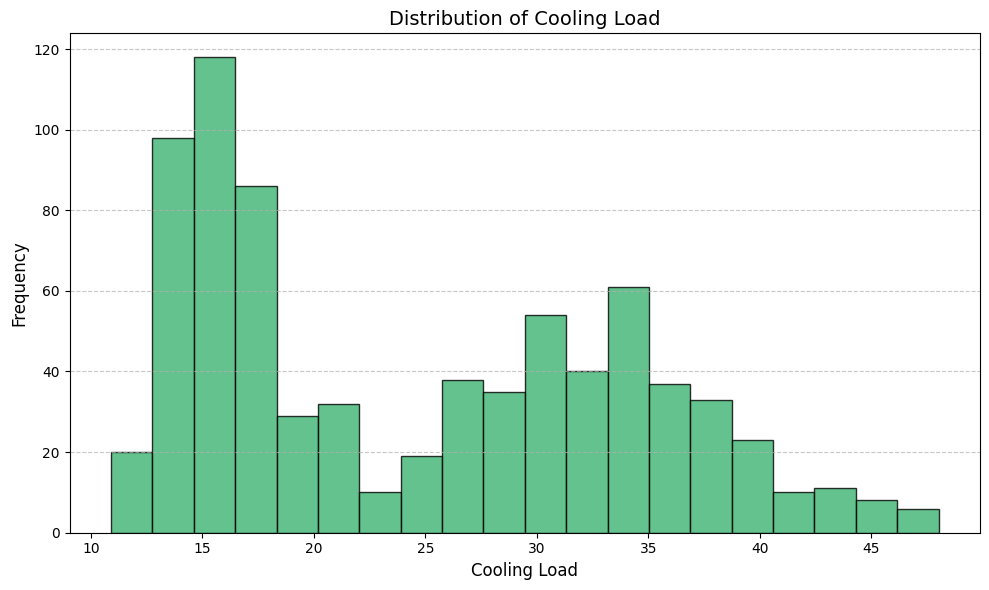

In [35]:
# Histogram – MPG Distribution
plt.figure(figsize=(10, 6))
plt.hist(data["cooling_load"], bins=20, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title("Distribution of Cooling Load", fontsize=14)
plt.xlabel("Cooling Load", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(results_dir + "08_histogram_cooling_load.png", dpi=400)
plt.show()

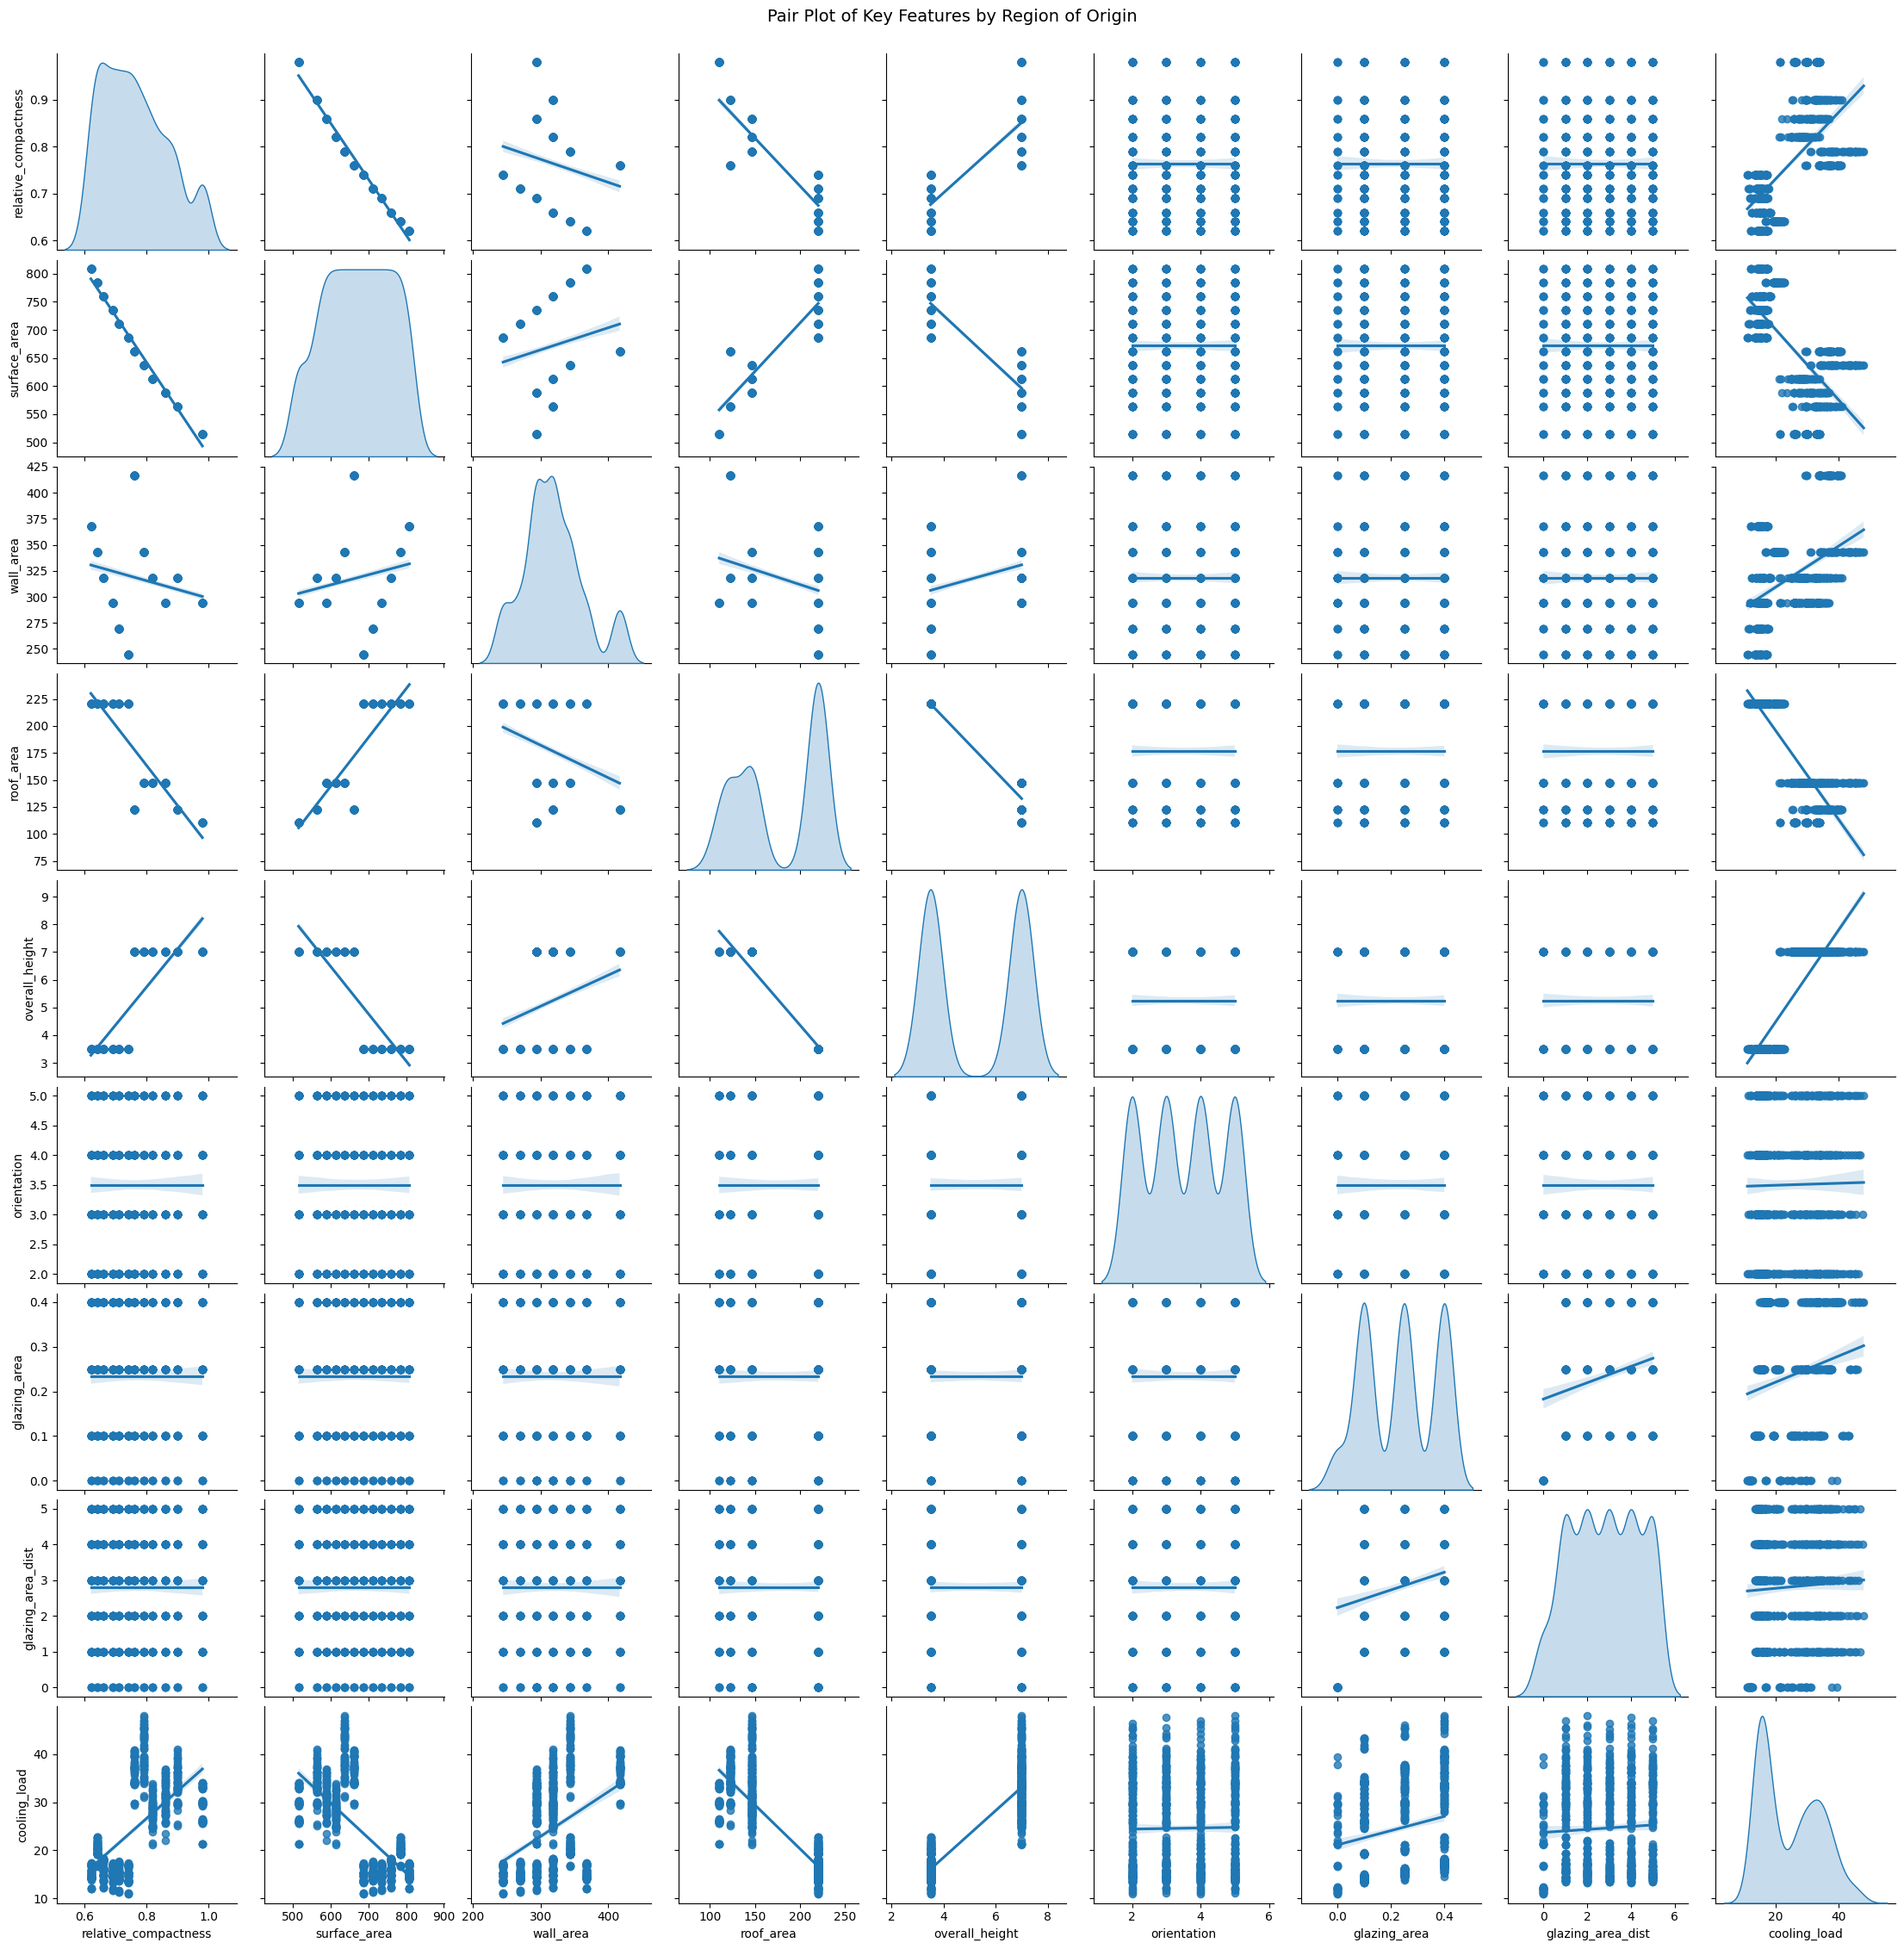

In [36]:
# Pair Plot – All Numeric Features coloured by Origin

g = sns.pairplot(data, 
                 kind="reg", 
                 diag_kind="kde")
g.figure.suptitle("Pair Plot of Key Features by Region of Origin", fontsize=14, y=1.01)
plt.savefig(results_dir + "22_pairplot.png", dpi=400, bbox_inches='tight')
plt.show()

### PyCaret Implementation

In [37]:
data.columns

Index(['relative_compactness', 'surface_area', 'wall_area', 'roof_area',
       'overall_height', 'orientation', 'glazing_area', 'glazing_area_dist',
       'cooling_load'],
      dtype='object')

In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   relative_compactness  768 non-null    float64
 1   surface_area          768 non-null    float64
 2   wall_area             768 non-null    float64
 3   roof_area             768 non-null    float64
 4   overall_height        768 non-null    float64
 5   orientation           768 non-null    float64
 6   glazing_area          768 non-null    float64
 7   glazing_area_dist     768 non-null    float64
 8   cooling_load          768 non-null    float64
dtypes: float64(9)
memory usage: 60.0 KB


In [39]:
from pycaret.regression import *

s = setup(data, target = 'cooling_load', session_id = 123)

,Description,Value
0,Session id,123
1,Target,cooling_load
2,Target type,Regression
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(537, 9)"
6,Transformed test set shape,"(231, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [40]:
# compare baseline models using PyCaret.
best = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,0.5555,0.7363,0.8342,0.9920,0.0271,0.0210,0.1580
xgboost,Extreme Gradient Boosting,0.6657,1.2548,1.0725,0.9865,0.0331,0.0240,0.0420
lightgbm,Light Gradient Boosting Machine,0.8923,1.7792,1.3019,0.9807,0.0396,0.0316,0.6940
gbr,Gradient Boosting Regressor,1.0736,2.4714,1.5545,0.9727,0.0474,0.0386,0.0130
rf,Random Forest Regressor,1.0759,3.1218,1.7143,0.9661,0.0509,0.0367,0.0280
et,Extra Trees Regressor,1.1286,3.9377,1.9248,0.9565,0.0559,0.0381,0.0250
knn,K Neighbors Regressor,1.6253,4.7335,2.1585,0.9478,0.0806,0.0672,0.0080
dt,Decision Tree Regressor,1.2152,5.1517,2.2274,0.9428,0.0664,0.0420,0.0070
ada,AdaBoost Regressor,1.8377,5.4173,2.3096,0.9400,0.0804,0.0723,0.0140
lr,Linear Regression,2.2895,10.5538,3.2013,0.8841,0.1110,0.0896,0.3330


In [41]:
data.head()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_dist,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2.0,0.0,0.0,21.33
1,0.98,514.5,294.0,110.25,7.0,3.0,0.0,0.0,21.33
2,0.98,514.5,294.0,110.25,7.0,4.0,0.0,0.0,21.33
3,0.98,514.5,294.0,110.25,7.0,5.0,0.0,0.0,21.33
4,0.90,563.5,318.5,122.50,7.0,2.0,0.0,0.0,28.28


In [42]:
data.isnull().sum()

relative_compactness    0
surface_area            0
wall_area               0
roof_area               0
overall_height          0
orientation             0
glazing_area            0
glazing_area_dist       0
cooling_load            0
dtype: int64

In [43]:
# Separating predictors from target
X = data.drop(["cooling_load"], axis=1)
y = data["cooling_load"]

# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, 
)

In [44]:
X_train

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_dist
318,0.71,710.5,269.5,220.50,3.5,4.0,0.25,1.0
313,0.74,686.0,245.0,220.50,3.5,3.0,0.25,1.0
195,0.98,514.5,294.0,110.25,7.0,5.0,0.10,4.0
570,0.64,784.0,343.0,220.50,3.5,4.0,0.40,1.0
226,0.69,735.0,294.0,220.50,3.5,4.0,0.10,4.0
...,...,...,...,...,...,...,...,...
98,0.98,514.5,294.0,110.25,7.0,4.0,0.10,2.0
322,0.69,735.0,294.0,220.50,3.5,4.0,0.25,1.0
382,0.62,808.5,367.5,220.50,3.5,4.0,0.25,2.0
365,0.71,710.5,269.5,220.50,3.5,3.0,0.25,2.0


In [45]:
X_test

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_dist
236,0.62,808.5,367.5,220.50,3.5,2.0,0.10,4.0
395,0.86,588.0,294.0,147.00,7.0,5.0,0.25,3.0
36,0.66,759.5,318.5,220.50,3.5,2.0,0.00,0.0
210,0.79,637.0,343.0,147.00,7.0,4.0,0.10,4.0
483,0.98,514.5,294.0,110.25,7.0,5.0,0.25,5.0
...,...,...,...,...,...,...,...,...
650,0.74,686.0,245.0,220.50,3.5,4.0,0.40,3.0
579,0.98,514.5,294.0,110.25,7.0,5.0,0.40,2.0
119,0.76,661.5,416.5,122.50,7.0,5.0,0.10,2.0
593,0.79,637.0,343.0,147.00,7.0,3.0,0.40,2.0


In [46]:
# Define models

models = {
    "LightGBM": LGBMRegressor(device='gpu', verbose=1),
    "CatBoost": CatBoostRegressor(task_type="GPU", verbose=100),
    "ExtraTrees": ExtraTreesRegressor(),
    "RandomForest": RandomForestRegressor()
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 57
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] Using GPU Device: Quadro RTX 4000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 8 dense feature groups (0.00 MB) transferred to GPU in 0.000176 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 24.906140
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [47]:
for key, result in results.items():
    print(f"{key}: {result}")

LightGBM: {'MAE': 0.7238143460414781, 'MSE': 1.1287717292001023, 'RMSE': 1.0624366942082255, 'R2': 0.9844973401034864}
CatBoost: {'MAE': 0.5418138676892917, 'MSE': 0.709871677486026, 'RMSE': 0.8425388284738135, 'R2': 0.9902505538528751}
ExtraTrees: {'MAE': 0.7974301948051937, 'MSE': 1.8650345952110363, 'RMSE': 1.3656626945227128, 'R2': 0.9743854348254474}
RandomForest: {'MAE': 0.8157512987012981, 'MSE': 1.7382101811038988, 'RMSE': 1.318411992172363, 'R2': 0.9761272535719806}


In [48]:
# Ensemble: Averaging
ensemble = VotingRegressor([
    ('lgbm', models["LightGBM"]),
    ('catboost', models["CatBoost"]),
    ('extra_trees', models["ExtraTrees"]),
    ('rf', models["RandomForest"]),
])

In [49]:
# Example: train and evaluate
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 57
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] Using GPU Device: Quadro RTX 4000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 8 dense feature groups (0.00 MB) transferred to GPU in 0.000195 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 24.906140
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [50]:
# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Ensemble R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Ensemble R²: 0.9842
MAE: 0.6809
MSE: 1.1477
RMSE: 1.0713


### After scaling

In [51]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [52]:
import pickle

# Save scaler
with open("../results/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [53]:
# Define models
models = {
    "LightGBM": LGBMRegressor(device='gpu', verbose=1),
    "CatBoost": CatBoostRegressor(task_type="GPU", verbose=100),
    "ExtraTrees": ExtraTreesRegressor(),
    "RandomForest": RandomForestRegressor()
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}


[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 59
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] Using GPU Device: Quadro RTX 4000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 8 dense feature groups (0.00 MB) transferred to GPU in 0.000239 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 24.906140
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [54]:
for key, result in results.items():
    print(f"{key}: {result}")

LightGBM: {'MAE': 0.7238143487209507, 'MSE': 1.1287717869354357, 'RMSE': 1.0624367213794126, 'R2': 0.9844973393105438}
CatBoost: {'MAE': 0.5418138676892917, 'MSE': 0.709871677486026, 'RMSE': 0.8425388284738135, 'R2': 0.9902505538528751}
ExtraTrees: {'MAE': 0.8218607142857126, 'MSE': 1.9679082236525902, 'RMSE': 1.4028215223800176, 'R2': 0.9729725584813703}
RandomForest: {'MAE': 0.8457896103896091, 'MSE': 1.9373211787012974, 'RMSE': 1.3918768547185838, 'R2': 0.9733926439094979}


In [55]:
# Ensemble: Averaging
ensemble = VotingRegressor([
    ('lgbm', models["LightGBM"]),
    ('catboost', models["CatBoost"]),
    ('extra_trees', models["ExtraTrees"]),
    ('rf', models["RandomForest"]),
])

In [56]:
# Example: train and evaluate
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 59
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] Using GPU Device: Quadro RTX 4000, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 8 dense feature groups (0.00 MB) transferred to GPU in 0.000208 secs. 0 sparse feature groups
[LightGBM] [Info] Start training from score 24.906140
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [57]:
# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Ensemble R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

Ensemble R²: 0.9846
MAE: 0.6798
MSE: 1.1230
RMSE: 1.0597


In [58]:
best_model = models["CatBoost"]

catboost R²: 0.9903
catboost MAE: 0.5418
catboost MSE: 0.7099
catboost RMSE: 0.8425


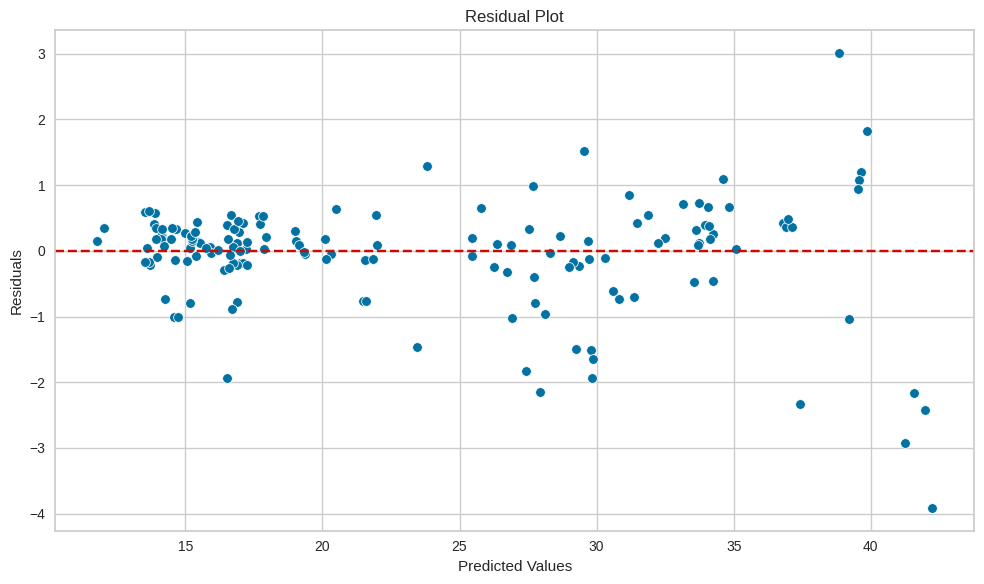

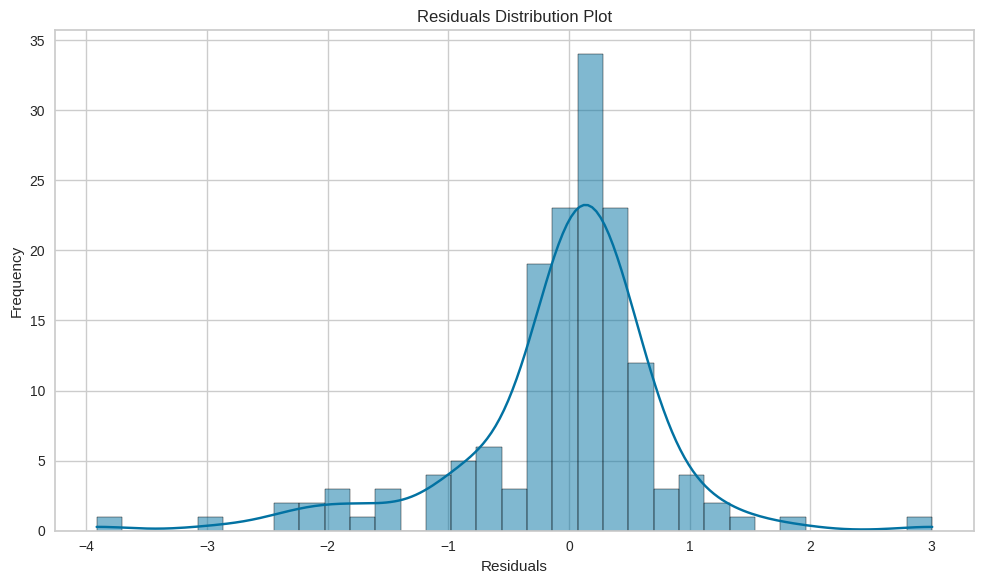

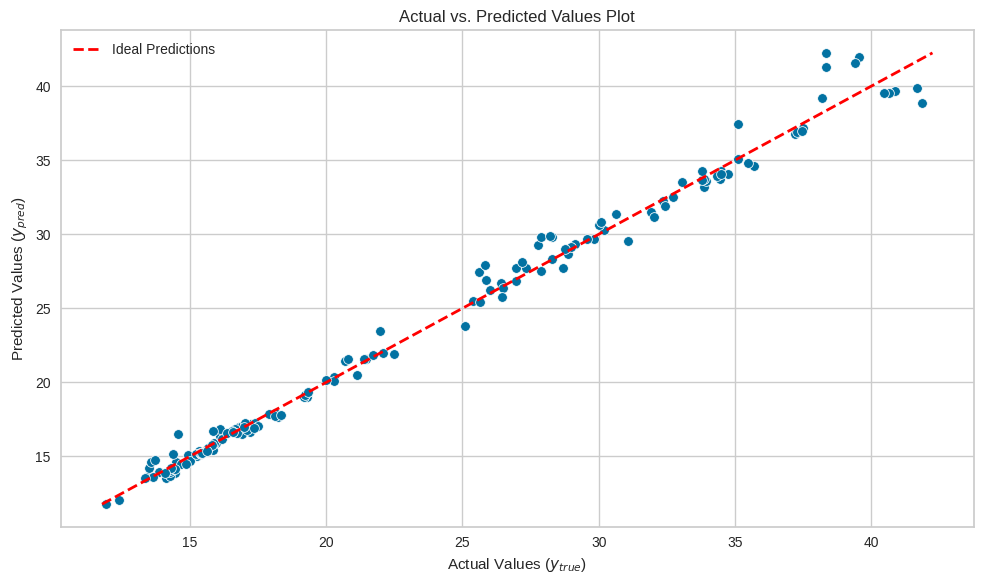

\catboost model saved to best_catboost_model.pkl


In [59]:
from evaluate_model import *

model_evaluation(best_model, X_test, y_test, results_dir, name="catboost")

### Apply PSO to Your CatBoost Model

In [60]:
# Define Objetive Function

def objective_function(x):
    x = np.array(x).reshape(1, -1)
    return best_model.predict(x)[0] # Minimize this

In [61]:
 # Define Bunds for x1-x8 (features)

lb = X_train.min(axis=0)   # lower bounds per feature
ub = X_train.max(axis=0)   # upper bounds per feature

In [62]:
type(X_train)

numpy.ndarray

In [63]:
# Run PSO
from pyswarm import pso

best_x, best_y = pso(objective_function, lb, ub, swarmsize=30, maxiter=50)

Stopping search: maximum iterations reached --> 50


In [64]:
print("Optimal Features (X1–X8):", best_x)
print("Minimum Cooling Load (Y2):", best_y)

Optimal Features (X1–X8): [-0.58139718  0.29729069 -0.94111946  0.20441148 -1.02640718 -1.32920682
 -0.89294434 -1.79584156]
Minimum Cooling Load (Y2): 12.88117511928224


In [65]:
### Inverse Scaling
## Convert back to actual values
best_x_actual = scaler.inverse_transform([best_x])[0]

In [66]:
## Assign to variables (4 decimal places)
features = [
    "Relative Compactness (X1)",
    "Surface Area (X2)",
    "Wall Area (X3)",
    "Roof Area (X4)",
    "Overall Height (X5)",
    "Orientation (X6)",
    "Glazing Area (X7)",
    "Glazing Area Distribution (X8)"
]

for name, value in zip(features, best_x_actual):
    print(f"{name}: {value:.4f}")

print(f"\nMinimum Cooling Load (Y2): {best_y:.4f}")

Relative Compactness (X1): 0.7056
Surface Area (X2): 695.3195
Wall Area (X3): 277.0984
Roof Area (X4): 184.6016
Overall Height (X5): 3.5000
Orientation (X6): 2.0000
Glazing Area (X7): 0.1167
Glazing Area Distribution (X8): 0.0000

Minimum Cooling Load (Y2): 12.8812
